In [13]:
"""
01 - Data Loading and Inspection
=================================
AI Drug Discovery Clinical Trials - RAG Portfolio Project

This notebook loads and performs initial inspection of the master clinical trials dataset
combining AACT metadata, PubMed publications, PDF documents, and FDA labels.

Author: [Your Name]
Date: 2026-01-25
"""

import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Add src to path
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'src'))

from biotech_rag.data.load import (
    load_master_dataset, 
    load_rag_ready_subset,
    load_dataset_summary,
    validate_data_paths
)
from biotech_rag.config import (
    DATA_DIR, 
    PROCESSED_DATA_DIR, 
    INTERIM_DATA_DIR,
    REPORTS_DIR,
    FIGURES_DIR
)

# Visualization setup
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline
%load_ext autoreload
%autoreload 2

print(f"✓ Setup complete")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Setup complete


# 📋 Project Overview

## Objective
Build a **Retrieval-Augmented Generation (RAG) system** to predict Phase III clinical trial success from trial documents, demonstrating advanced LLM + LangChain + Vector DB skills for biotech recruiters.

## Dataset Description

### Data Sources (5 total)
1. **AACT Database** (ClinicalTrials.gov): Trial metadata, design, outcomes
2. **PMC Publications**: Peer-reviewed trial publications with PMCIDs
3. **PubMed XML**: Full-text abstracts, MeSH terms, keywords
4. **PDF Documents**: Full trial publications for RAG retrieval
5. **FDA Labels**: Drug approval information (when available)

### Key Files
- `master_ai_trials_dataset.csv`: Complete dataset (~127 trials, all data sources)
- `rag_ready_trials.csv`: Trials with PDF or XML for RAG pipeline (~29-70 trials)
- `dataset_summary.json`: Dataset statistics and metadata

### Expected Shape
- **Rows:** ~127 clinical trials (NCT IDs)
- **Columns:** ~60+ features across 5 data sources
- **Target:** `success_flag` (LIKELY_PASS, LIKELY_FAIL, DEFINITE_FAIL, NO_RESULTS)

### Known Data Characteristics
- **Imbalanced classes**: More LIKELY_PASS than DEFINITE_FAIL
- **Missing data**: Not all trials have PDFs, FDA labels, or publications
- **Multi-source**: Columns prefixed by source (pmc_, xml_, fda_)
- **Data richness varies**: Measured by `data_richness_score` (0-100)

### Focus Area
**AI-designed drugs and computational drug discovery** trials from companies like Insilico Medicine, Exscientia, BenevolentAI.

In [7]:
# ============================================================================
# LOAD MASTER DATASET
# ============================================================================

print("LOADING CLINICAL TRIALS DATA")
print("\n" + "-"*70)

# Load master dataset
try:
    master_df = load_master_dataset()
    load_success = True
    print(f"✓ Master dataset loaded: {len(master_df)} trials")
    print(f"  Columns: {master_df.shape}")
    print(f"  Memory: {master_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
except FileNotFoundError as e:
    print(f"✗ Error: {e}")
    load_success = False
    master_df = None

# Load RAG-ready subset
try:
    rag_df = load_rag_ready_subset()
    print(f"✓ RAG-ready subset loaded: {len(rag_df)} trials")
except FileNotFoundError as e:
    print(f"⚠ RAG subset not found: {e}")
    rag_df = None

# Load dataset summary
try:
    summary = load_dataset_summary()
    print(f"✓ Dataset summary loaded")
    print(f"  Created: {summary.get('creation_date', 'Unknown')}")
except FileNotFoundError as e:
    print(f"⚠ Summary not found: {e}")
    summary = {}

print("Data loaded")

# Stop execution if load failed
if not load_success:
    raise RuntimeError("Failed to load master dataset. Check file paths.")

INFO:biotech_rag.data.load:✓ Loaded master dataset: 127 trials, (127, 53) columns
INFO:biotech_rag.data.load:✓ Loaded RAG-ready subset: 75 trials
INFO:biotech_rag.data.load:✓ Loaded dataset summary


LOADING CLINICAL TRIALS DATA

----------------------------------------------------------------------
✓ Master dataset loaded: 127 trials
  Columns: (127, 53)
  Memory: 0.70 MB
✓ RAG-ready subset loaded: 75 trials
✓ Dataset summary loaded
  Created: 2026-01-25T17:08:54.914263
Data loaded


In [9]:
# ============================================================================
# COMPREHENSIVE DATA PROFILE
# ============================================================================

print("📊 DATASET OVERVIEW\n")

# Shape
print(f"Shape: {master_df.shape} rows × {master_df.shape} columns\n")

# Data types summary
print("Data Types Summary:")
dtype_counts = master_df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {str(dtype):15s}: {count:3d} columns")

print("\n" + "-"*70)

# First 10 rows
print("\nFirst 10 Rows:")
display(master_df.head(10))

print("\n" + "-"*70)

# Last 10 rows
print("\nLast 10 Rows:")
display(master_df.tail(10))

print("\n" + "-"*70)

# Detailed info
print("\nDetailed Column Information:")
master_df.info(verbose=True, show_counts=True)

print("\n" + "-"*70)

# Summary statistics (all columns)
print("\nSummary Statistics (All Columns):")
summary_stats = master_df.describe(include='all').T
summary_stats['dtype'] = master_df.dtypes
display(summary_stats)

print("\n" + "-"*70)

# Memory usage
print("\nMemory Usage by Column:")
mem_usage = master_df.memory_usage(deep=True).sort_values(ascending=False)
mem_usage_mb = mem_usage / 1024**2
print(mem_usage_mb.head(15).to_string())
print(f"\nTotal memory: {mem_usage_mb.sum():.2f} MB")

📊 DATASET OVERVIEW

Shape: (127, 53) rows × (127, 53) columns

Data Types Summary:
  object         :  37 columns
  float64        :   8 columns
  bool           :   5 columns
  int64          :   3 columns

----------------------------------------------------------------------

First 10 Rows:


,nct_id,brief_title,official_title,overall_status,phase,study_type,enrollment,start_date,completion_date,primary_completion_date,...,fda_substance_name,fda_indications,fda_warnings,has_pmc_publication,has_pubmed_xml,has_fda_label,data_richness_score,rag_ready,priority_rank,richness_bin
0,NCT04205812,Platinum-Based Chemotherapy With/Without INCMG...,"A Randomized, Double Blind, Phase 3 Study of P...",ACTIVE_NOT_RECRUITING,PHASE3,INTERVENTIONAL,583,2020-09-11,2026-08-28,2023-12-15,...,PACLITAXEL,"INDICATIONS AND USAGE Paclitaxel Injection, US...",WARNINGS Anaphylaxis and severe hypersensitivi...,True,True,True,100,True,103,76-100%
1,NCT04194944,A Study of Selpercatinib (LY3527723) in Partic...,"LIBRETTO-431: A Multicenter, Randomized, Open-...",ACTIVE_NOT_RECRUITING,PHASE3,INTERVENTIONAL,261,2020-02-17,2030-06-30,2023-05-01,...,SELPERCATINIB,1 INDICATIONS AND USAGE RETEVMO ® is a kinase ...,NaN,True,True,True,100,True,103,76-100%
2,NCT03594747,A Study of Tislelizumab in Combination With Ch...,"A Phase 3, Multicenter, Randomized Open-Label ...",COMPLETED,PHASE3,INTERVENTIONAL,360,2018-07-30,2023-04-28,2020-09-30,...,TISLELIZUMAB,1 INDICATIONS AND USAGE TEVIMBRA is a programm...,NaN,True,True,True,100,True,103,76-100%
3,NCT03663205,A Study Evaluating the Efficacy and Safety of ...,"A Phase 3, Open-Label, Multicenter, Randomized...",COMPLETED,PHASE3,INTERVENTIONAL,334,2018-07-23,2023-04-26,2020-01-23,...,PEMETREXED DISODIUM HEMIPENTAHYDRATE,1 INDICATIONS AND USAGE Pemetrexed for Injecti...,NaN,True,True,True,100,True,103,76-100%
4,NCT04035486,A Study of Osimertinib With or Without Chemoth...,"A Phase III, Open-label, Randomized Study of O...",ACTIVE_NOT_RECRUITING,PHASE3,INTERVENTIONAL,587,2019-07-02,2026-12-22,2023-04-03,...,OSIMERTINIB,1 INDICATIONS AND USAGE TAGRISSO is a kinase i...,NaN,True,True,True,100,True,103,76-100%
5,NCT03703297,"Study of Durvalumab + Tremelimumab, Durvalumab...","A Phase III, Randomized, Double-blind, Placebo...",ACTIVE_NOT_RECRUITING,PHASE3,INTERVENTIONAL,730,2018-09-27,2026-10-23,2024-01-15,...,DURVALUMAB,1 INDICATIONS AND USAGE IMFINZI is a programme...,NaN,True,True,True,100,True,103,76-100%
6,NCT03515837,Study of Pemetrexed + Platinum Chemotherapy Wi...,"A Randomized, Double-Blind, Phase 3 Study of P...",COMPLETED,PHASE3,INTERVENTIONAL,492,2018-06-29,2023-10-02,2023-01-17,...,CARBOPLATIN,INDICATIONS Initial Treatment of Advanced Ovar...,"WARNINGS Bone marrow suppression (leukopenia, ...",True,True,True,100,True,103,76-100%
7,NCT03829332,Efficacy and Safety Study of Pembrolizumab (MK...,"A Phase 3, Randomized, Double-blind Trial of P...",COMPLETED,PHASE3,INTERVENTIONAL,623,2019-03-13,2024-04-24,2021-05-19,...,LENVATINIB,1 INDICATIONS AND USAGE LENVIMA is a kinase in...,NaN,True,True,True,100,True,103,76-100%
8,NCT05091567,"A Phase III, Open-Label Study of Maintenance L...","A Phase III, Randomized, Open-Label, Multicent...",ACTIVE_NOT_RECRUITING,PHASE3,INTERVENTIONAL,660,2021-11-18,2026-08-13,2024-07-29,...,LURBINECTEDIN,1 INDICATIONS AND USAGE ZEPZELCA is an alkylat...,NaN,True,True,True,100,True,103,76-100%
9,NCT03425643,Efficacy and Safety of Pembrolizumab (MK-3475)...,"A Phase III, Randomized, Double-blind Trial of...",ACTIVE_NOT_RECRUITING,PHASE3,INTERVENTIONAL,797,2018-04-24,2026-06-29,2023-07-10,...,PEMETREXED DISODIUM HEMIPENTAHYDRATE,1 INDICATIONS AND USAGE Pemetrexed for Injecti...,NaN,True,True,True,100,True,103,76-100%



----------------------------------------------------------------------

Last 10 Rows:


,nct_id,brief_title,official_title,overall_status,phase,study_type,enrollment,start_date,completion_date,primary_completion_date,...,fda_substance_name,fda_indications,fda_warnings,has_pmc_publication,has_pubmed_xml,has_fda_label,data_richness_score,rag_ready,priority_rank,richness_bin
117,NCT05353257,A Study to Evaluate the Efficacy and Safety of...,"A Randomized, Double-Blind, International Mult...",ACTIVE_NOT_RECRUITING,PHASE3,INTERVENTIONAL,511,2022-05-17,2028-05-30,2026-06-30,...,NaN,NaN,NaN,True,False,False,25,False,20,0-25%
118,NCT05450692,A Phase III Study of Ceralasertib Plus Durvalu...,"A Phase III, Open-label, Randomised, Multicent...",ACTIVE_NOT_RECRUITING,PHASE3,INTERVENTIONAL,594,2022-09-15,2026-10-30,2025-10-06,...,NaN,NaN,NaN,True,False,False,25,False,20,0-25%
119,NCT05468489,To Evaluate Efficacy and Safety of Serplulimab...,"A Randomized, Open-label Study of Serplulimab ...",ACTIVE_NOT_RECRUITING,PHASE3,INTERVENTIONAL,200,2022-11-18,2027-12-31,2026-02-28,...,NaN,NaN,NaN,True,False,False,25,False,20,0-25%
120,NCT04921358,Tislelizumab in Combination With Sitravatinib ...,A Randomized Phase 3 Study of Tislelizumab in ...,TERMINATED,PHASE3,INTERVENTIONAL,377,2021-07-27,2023-12-20,2023-12-20,...,NaN,NaN,NaN,True,False,False,25,False,20,0-25%
121,NCT04619433,A Study to Evaluate SHR-1210 in Combination Wi...,"A Multi-center, Randomized, Double-blind, Phas...",TERMINATED,PHASE3,INTERVENTIONAL,48,2021-02-01,2025-08-16,2025-08-16,...,NaN,NaN,NaN,True,False,False,25,False,20,0-25%
122,NCT04774380,Study of Durvalumab in Combination With Platin...,"A Phase IIIb, Single-arm, Multi-center, Intern...",COMPLETED,PHASE3,INTERVENTIONAL,152,2021-11-11,2025-01-02,2023-06-12,...,ETOPOSIDE,INDICATIONS AND USAGE Etoposide Injection is i...,WARNINGS Patients being treated with etoposide...,False,False,True,20,False,15,0-25%
123,NCT05047250,A Study of Atezolizumab in High PD-L1 Expressi...,"A Phase III, Single-Arm Multicenter Study of A...",ACTIVE_NOT_RECRUITING,PHASE3,INTERVENTIONAL,60,2022-06-14,2027-08-30,2026-06-30,...,ATEZOLIZUMAB,1 INDICATIONS AND USAGE TECENTRIQ is a program...,NaN,False,False,True,20,False,15,0-25%
124,NCT06348199,"A Study to Compare the Efficacy, Safety, Pharm...","A Phase III Randomised, Double-blind, Multicen...",ACTIVE_NOT_RECRUITING,PHASE3,INTERVENTIONAL,555,2024-03-12,2026-09-30,2026-03-31,...,NaN,NaN,NaN,False,False,False,0,False,0,0-25%
125,NCT06082635,TGRX-326 Chinese Phase III for Advanced Non-sm...,"A Multi-centered, Randomized, Open-label Phase...",ACTIVE_NOT_RECRUITING,PHASE3,INTERVENTIONAL,321,2023-12-14,2028-11-30,2026-04-30,...,NaN,NaN,NaN,False,False,False,0,False,0,0-25%
126,NCT06505837,JS001sc or JS001 Plus Chemotherapy is Indicate...,"Open-Label, Randomized, Phase III Clinical Stu...",ACTIVE_NOT_RECRUITING,PHASE3,INTERVENTIONAL,395,2024-07-11,2026-12-30,2026-06-30,...,NaN,NaN,NaN,False,False,False,0,False,0,0-25%



----------------------------------------------------------------------

Detailed Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 53 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   nct_id                       127 non-null    object 
 1   brief_title                  127 non-null    object 
 2   official_title               127 non-null    object 
 3   overall_status               127 non-null    object 
 4   phase                        127 non-null    object 
 5   study_type                   127 non-null    object 
 6   enrollment                   127 non-null    int64  
 7   start_date                   127 non-null    object 
 8   completion_date              127 non-null    object 
 9   primary_completion_date      127 non-null    object 
 10  why_stopped                  11 non-null     object 
 11  intervention_type            127 n

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,dtype
nct_id,127,127,NCT04205812,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
brief_title,127,126,A Study to Evaluate the Efficacy and Safety of...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
official_title,127,123,"A Phase 3, Randomized, Double-blind Trial of P...",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
overall_status,127,3,ACTIVE_NOT_RECRUITING,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
phase,127,1,PHASE3,127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
study_type,127,1,INTERVENTIONAL,127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
enrollment,127.0,NaN,NaN,NaN,444.937008,265.603707,25.0,263.0,432.0,586.5,1538.0,int64
start_date,127,125,2019-07-23,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
completion_date,127,110,2025-12-31,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
primary_completion_date,127,112,2026-06-30,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object



----------------------------------------------------------------------

Memory Usage by Column:
xml_abstract             0.265390
fda_indications          0.051151
official_title           0.038322
pmc_title                0.025630
brief_title              0.025098
xml_mesh_terms           0.020633
xml_title                0.017241
fda_warnings             0.014264
xml_publication_types    0.011047
condition_name           0.010664
pmc_authors              0.010026
sponsor_name             0.009621
intervention_name        0.008981
overall_status           0.008874
xml_journal              0.008775

Total memory: 0.70 MB


In [14]:
# ============================================================================
# DETAILED COLUMN ANALYSIS
# ============================================================================

print("🔍 COLUMN-BY-COLUMN ANALYSIS\n")
print("="*70)

# Key column groups
key_columns = {
    'Trial Identifiers': ['nct_id', 'brief_title', 'official_title'],
    'Trial Design': ['phase', 'overall_status', 'study_type', 'enrollment'],
    'Intervention': ['intervention_name', 'intervention_type', 'condition_name'],
    'Outcomes': ['success_flag', 'primary_outcome', 'p_value'],
    'Sponsor': ['sponsor_name'],
    'PMC Data': [col for col in master_df.columns if col.startswith('pmc_')],
    'PubMed XML': [col for col in master_df.columns if col.startswith('xml_')],
    'FDA Labels': [col for col in master_df.columns if col.startswith('fda_')],
    'Data Flags': ['has_pmc_publication', 'has_pubmed_xml', 'has_pdf', 'has_fda_label', 'rag_ready'],
    'Scores': ['data_richness_score', 'priority_rank']
}

for group_name, columns in key_columns.items():
    # Filter to existing columns
    existing_cols = [col for col in columns if col in master_df.columns]
    
    if not existing_cols:
        continue
    
    print(f"\n{group_name}")
    print("-"*70)
    
    for col in existing_cols:
        print(f"\n {col}")
        print(f"   Type: {master_df[col].dtype}")
        print(f"   Non-null: {master_df[col].notna().sum():,} ({master_df[col].notna().mean()*100:.1f}%)")
        print(f"   Unique: {master_df[col].nunique():,}")
        
        # Numeric columns
        if pd.api.types.is_numeric_dtype(master_df[col]):
            print(f"   Min: {master_df[col].min()}")
            print(f"   Max: {master_df[col].max()}")
            print(f"   Mean: {master_df[col].mean():.2f}")
            print(f"   Median: {master_df[col].median():.2f}")
        
        # Categorical/Object columns
        elif pd.api.types.is_object_dtype(master_df[col]) or pd.api.types.is_categorical_dtype(master_df[col]):
            value_counts = master_df[col].value_counts().head(10)
            if len(value_counts) > 0:
                print(f"   Top values:")
                for val, count in value_counts.items():
                    val_str = str(val)[:50]  # Truncate long strings
                    pct = (count / len(master_df)) * 100
                    print(f"     - {val_str}: {count} ({pct:.1f}%)")
        
        # Sample values
        sample = master_df[col].dropna().head(3).tolist()
        if sample:
            print(f"   Sample: {sample}")

print("\n" + "="*70)

🔍 COLUMN-BY-COLUMN ANALYSIS


Trial Identifiers
----------------------------------------------------------------------

 nct_id
   Type: object
   Non-null: 127 (100.0%)
   Unique: 127
   Top values:
     - NCT04205812: 1 (0.8%)
     - NCT04194944: 1 (0.8%)
     - NCT03594747: 1 (0.8%)
     - NCT03663205: 1 (0.8%)
     - NCT04035486: 1 (0.8%)
     - NCT03703297: 1 (0.8%)
     - NCT03515837: 1 (0.8%)
     - NCT03829332: 1 (0.8%)
     - NCT05091567: 1 (0.8%)
     - NCT03425643: 1 (0.8%)
   Sample: ['NCT04205812', 'NCT04194944', 'NCT03594747']

 brief_title
   Type: object
   Non-null: 127 (100.0%)
   Unique: 126
   Top values:
     - A Study to Evaluate the Efficacy and Safety of Ana: 2 (1.6%)
     - Platinum-Based Chemotherapy With/Without INCMGA000: 1 (0.8%)
     - A Study of Tislelizumab in Combination With Chemot: 1 (0.8%)
     - A Study Evaluating the Efficacy and Safety of Tisl: 1 (0.8%)
     - A Study of Osimertinib With or Without Chemotherap: 1 (0.8%)
     - A Study of Selpercat

🔎 DATA QUALITY CHECKS


1. Missing Values Analysis
----------------------------------------------------------------------

Columns with missing data (30 total):


,Missing_Count,Missing_Percent
why_stopped,116,91.338583
fda_warnings,105,82.677165
xml_keywords,100,78.740157
p_value,95,74.803150
primary_outcome,79,62.204724
death_percent,79,62.204724
enrolled_deaths,79,62.204724
enrolled_seriously_affected,79,62.204724
intervention_other_name,63,49.606299
xml_mesh_terms,61,48.031496


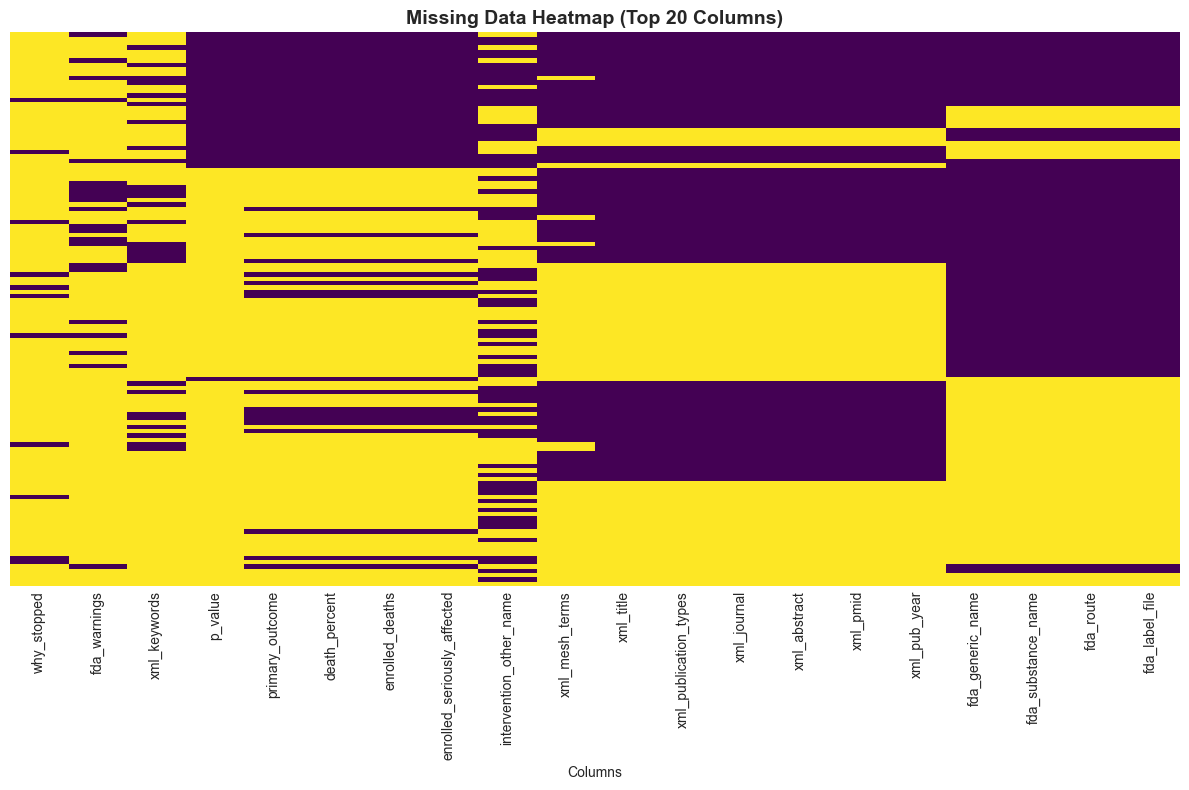


----------------------------------------------------------------------

2. Duplicate Rows Check
----------------------------------------------------------------------
Duplicate rows: 0 (0.00%)

----------------------------------------------------------------------

3. Data Type Validation
----------------------------------------------------------------------
✓ All numeric data properly typed

----------------------------------------------------------------------

4. Placeholder/Sentinel Value Detection
----------------------------------------------------------------------
✓ No common sentinel values detected



In [15]:
# ============================================================================
# DATA QUALITY ASSESSMENT
# ============================================================================

print("🔎 DATA QUALITY CHECKS\n")
print("="*70)

# Missing values analysis
print("\n1. Missing Values Analysis")
print("-"*70)

missing_counts = master_df.isnull().sum()
missing_pct = (missing_counts / len(master_df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percent': missing_pct
}).sort_values('Missing_Count', ascending=False)

# Show columns with missing data
missing_df_filtered = missing_df[missing_df['Missing_Count'] > 0]
if len(missing_df_filtered) > 0:
    print(f"\nColumns with missing data ({len(missing_df_filtered)} total):")
    display(missing_df_filtered.head(20))
    
    # Visualize missing data heatmap (top 20 columns)
    if len(missing_df_filtered) > 0:
        fig, ax = plt.subplots(figsize=(12, 8))
        top_missing_cols = missing_df_filtered.head(20).index.tolist()
        sns.heatmap(
            master_df[top_missing_cols].isnull(), 
            cbar=False, 
            yticklabels=False,
            cmap='viridis',
            ax=ax
        )
        ax.set_title('Missing Data Heatmap (Top 20 Columns)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Columns')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / '01_missing_data_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("✓ No missing values detected!")

print("\n" + "-"*70)

# Duplicate rows
print("\n2. Duplicate Rows Check")
print("-"*70)
duplicate_count = master_df.duplicated().sum()
duplicate_pct = (duplicate_count / len(master_df)) * 100
print(f"Duplicate rows: {duplicate_count} ({duplicate_pct:.2f}%)")

if duplicate_count > 0:
    print("\nSample duplicates:")
    display(master_df[master_df.duplicated(keep=False)].head(10))

print("\n" + "-"*70)

# Data type mismatches
print("\n3. Data Type Validation")
print("-"*70)

# Check for numeric columns stored as object
numeric_as_object = []
for col in master_df.select_dtypes(include='object').columns:
    # Try converting to numeric
    try:
        pd.to_numeric(master_df[col], errors='raise')
        numeric_as_object.append(col)
    except:
        pass

if numeric_as_object:
    print(f"⚠ Columns that could be numeric: {numeric_as_object}")
else:
    print("✓ All numeric data properly typed")

print("\n" + "-"*70)

# Sentinel/placeholder values
print("\n4. Placeholder/Sentinel Value Detection")
print("-"*70)

sentinel_values = ['N/A', 'Unknown', 'None', 'null', '-999', '999', 'NA', 'n/a']
sentinel_found = {}

for col in master_df.select_dtypes(include='object').columns:
    found_sentinels = []
    for sentinel in sentinel_values:
        count = (master_df[col] == sentinel).sum()
        if count > 0:
            found_sentinels.append((sentinel, count))
    
    if found_sentinels:
        sentinel_found[col] = found_sentinels

if sentinel_found:
    print("⚠ Sentinel values found:")
    for col, sentinels in list(sentinel_found.items())[:10]:  # Show first 10
        print(f"\n  {col}:")
        for val, count in sentinels:
            print(f"    - '{val}': {count} occurrences")
else:
    print("✓ No common sentinel values detected")

print("\n" + "="*70)

🎯 TARGET VARIABLE ANALYSIS


success_flag Distribution:
----------------------------------------------------------------------


,Count,Percentage
success_flag,,
NO_RESULTS,86,67.716535
LIKELY_PASS,19,14.960630
LIKELY_FAIL,11,8.661417
DEFINITE_FAIL,11,8.661417



Total: 127
Unique values: 4
Missing: 0


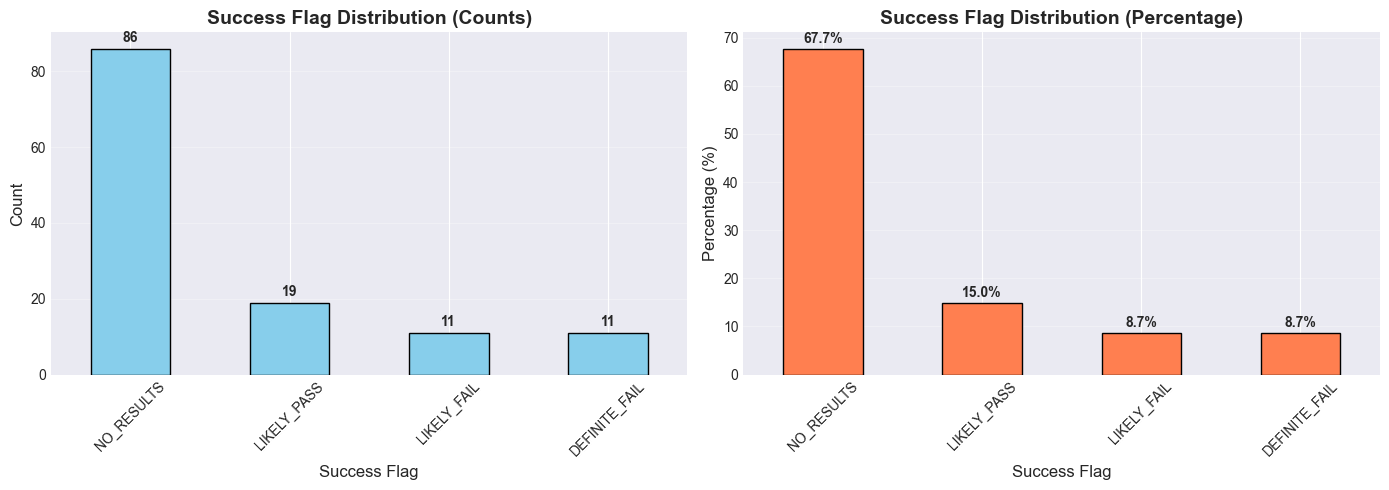


----------------------------------------------------------------------

Class Balance Assessment:
  Largest class: 86
  Smallest (positive) class: 11
  Imbalance ratio: 7.82:1

  ⚠ Dataset is imbalanced (ratio > 3:1 or zero-count class present)
     Consider: SMOTE, class weights, stratified sampling



In [17]:
# ============================================================================ 
# TARGET VARIABLE ANALYSIS: success_flag
# ============================================================================

print("🎯 TARGET VARIABLE ANALYSIS\n")
print("="*70)

target_col = 'success_flag'

if target_col in master_df.columns:
    # Value counts
    print(f"\n{target_col} Distribution:")
    print("-"*70)
    
    value_counts = master_df[target_col].value_counts(dropna=False)
    value_pcts = master_df[target_col].value_counts(normalize=True, dropna=False) * 100
    
    dist_df = pd.DataFrame({
        'Count': value_counts,
        'Percentage': value_pcts
    })
    display(dist_df)
    
    print(f"\nTotal: {len(master_df)}")
    print(f"Unique values: {master_df[target_col].nunique()}")
    print(f"Missing: {master_df[target_col].isna().sum()}")
    
    # Visualization: Bar chart (use individual axes correctly)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax0, ax1 = axes  # unpack axes array

    # Count plot
    value_counts.plot(kind='bar', ax=ax0, color='skyblue', edgecolor='black')
    ax0.set_title('Success Flag Distribution (Counts)', fontsize=14, fontweight='bold')
    ax0.set_xlabel('Success Flag', fontsize=12)
    ax0.set_ylabel('Count', fontsize=12)
    ax0.tick_params(axis='x', rotation=45)
    ax0.grid(axis='y', alpha=0.3)

    # Add value labels on bars (offset scaled to value)
    for i, (idx, val) in enumerate(value_counts.items()):
        offset = max(1, val * 0.01)
        ax0.text(i, val + offset, str(int(val)), ha='center', va='bottom', fontweight='bold')

    # Percentage plot
    value_pcts.plot(kind='bar', ax=ax1, color='coral', edgecolor='black') 
    ax1.set_title('Success Flag Distribution (Percentage)', fontsize=14, fontweight='bold') 
    ax1.set_xlabel('Success Flag', fontsize=12) 
    ax1.set_ylabel('Percentage (%)', fontsize=12) 
    ax1.tick_params(axis='x', rotation=45) 
    ax1.grid(axis='y', alpha=0.3) 

    # Add percentage labels
    for i, (idx, val) in enumerate(value_pcts.items()):
        ax1.text(i, val + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '01_target_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Class balance assessment
    print("\n" + "-"*70)
    print("\nClass Balance Assessment:")
    
    max_class = int(value_counts.max())
    nonzero = value_counts[value_counts > 0]
    min_class = int(nonzero.min()) if len(nonzero) > 0 else 0
    imbalance_ratio = (max_class / min_class) if min_class > 0 else np.inf
    
    print(f"  Largest class: {max_class}")
    print(f"  Smallest (positive) class: {min_class if min_class>0 else 'N/A'}")
    print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1" if np.isfinite(imbalance_ratio) else "  Imbalance ratio: inf (zero-count class present)")
    
    if not np.isfinite(imbalance_ratio) or imbalance_ratio > 3:
        print(f"\n  ⚠ Dataset is imbalanced (ratio > 3:1 or zero-count class present)")
        print(f"     Consider: SMOTE, class weights, stratified sampling")
    else:
        print(f"\n  ✓ Dataset is relatively balanced")

else:
    print(f"⚠ Target column '{target_col}' not found in dataset")

print("\n" + "="*70)

In [20]:
# ============================================================================
# SAVE DATA REPORTS
# ============================================================================

print("💾 SAVING DATA REPORTS\n")
print("="*70)

# Ensure reports directory exists
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save summary statistics
summary_file = REPORTS_DIR / '01_data_profile.csv'
summary_stats_full = master_df.describe(include='all').T
summary_stats_full['dtype'] = master_df.dtypes
summary_stats_full['missing_count'] = master_df.isnull().sum()
summary_stats_full['missing_pct'] = (master_df.isnull().sum() / len(master_df)) * 100
summary_stats_full.to_csv(summary_file)
print(f"✓ Data profile saved")

# 2. Save data quality issues
issues_file = REPORTS_DIR / '01_data_quality_issues.txt'
with open(issues_file, 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("DATA QUALITY ISSUES REPORT\n")
    f.write("="*70 + "\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Dataset: master_ai_trials_dataset.csv\n")
    f.write(f"Rows: {len(master_df):,}\n")
    f.write(f"Columns: {master_df.shape}\n\n") 
    
    # Missing data
    f.write("-"*70 + "\n")
    f.write("1. MISSING DATA\n")
    f.write("-"*70 + "\n")
    if len(missing_df_filtered) > 0:
        f.write(f"Columns with missing data: {len(missing_df_filtered)}\n\n")
        f.write(missing_df_filtered.to_string())
    else:
        f.write("✓ No missing data detected\n")
    
    # Duplicates
    f.write("\n\n" + "-"*70 + "\n")
    f.write("2. DUPLICATE ROWS\n")
    f.write("-"*70 + "\n")
    f.write(f"Duplicate count: {duplicate_count} ({duplicate_pct:.2f}%)\n")
    
    # Type mismatches
    f.write("\n" + "-"*70 + "\n")
    f.write("3. DATA TYPE ISSUES\n")
    f.write("-"*70 + "\n")
    if numeric_as_object:
        f.write(f"Columns stored as object that could be numeric:\n")
        for col in numeric_as_object:
            f.write(f"  - {col}\n")
    else:
        f.write("✓ No type mismatches detected\n")
    
    # Sentinels
    f.write("\n" + "-"*70 + "\n")
    f.write("4. SENTINEL VALUES\n")
    f.write("-"*70 + "\n")
    if sentinel_found:
        f.write(f"Columns with sentinel values: {len(sentinel_found)}\n")
        for col, sentinels in sentinel_found.items():
            f.write(f"\n  {col}:\n")
            for val, count in sentinels:
                f.write(f"    - '{val}': {count}\n")
    else:
        f.write("✓ No sentinel values detected\n")
    
    # Target balance
    if target_col in master_df.columns:
        f.write("\n" + "-"*70 + "\n")
        f.write("5. TARGET VARIABLE BALANCE\n")
        f.write("-"*70 + "\n")
        f.write(f"Target: {target_col}\n")
        f.write(f"Imbalance ratio: {imbalance_ratio:.2f}:1\n")
        f.write(f"\nDistribution:\n")
        f.write(dist_df.to_string())

print(f"✓ Quality issues saved")

# 3. Save data source coverage report
coverage_file = REPORTS_DIR / '01_data_source_coverage.csv'
coverage_data = []

for source in ['has_pmc_publication', 'has_pubmed_xml', 'has_pdf', 'has_fda_label']:
    if source in master_df.columns:
        count = master_df[source].sum()
        pct = (count / len(master_df)) * 100
        coverage_data.append({
            'data_source': source.replace('has_', ''),
            'count': int(count),
            'percentage': round(pct, 2)
        })

coverage_df = pd.DataFrame(coverage_data)
coverage_df.to_csv(coverage_file, index=False)
print(f"✓ Data source coverage saved")

print("\n" + "="*70)
print("✅ ALL REPORTS SAVED SUCCESSFULLY")
print("="*70)
print(f"\n📂 Output files:")
print(f"   - reports\01_data_profile.csv")
print(f"   - reports\01_data_quality_issues.txt")
print(f"   - reports\01_data_source_coverage.csv")
print(f"   - {'reports/01_missing_data_heatmap.png'}")
print(f"   - {'reports/01_target_distribution.png'}")

💾 SAVING DATA REPORTS

✓ Data profile saved
✓ Quality issues saved
✓ Data source coverage saved

✅ ALL REPORTS SAVED SUCCESSFULLY

📂 Output files:
   - reports_data_profile.csv
   - reports_data_quality_issues.txt
   - reports_data_source_coverage.csv
   - reports/01_missing_data_heatmap.png
   - reports/01_target_distribution.png
